# Lecture 6 — Practice: Debugging Training & Experiments (CV)

Это **практика без оценивания**.  
Цель — руками увидеть типовые поломки обучения и отработать *инженерный* алгоритм диагностики.

Что сделаем:
1) Sanity checks (shape/dtype/range)  
2) Overfit vs Underfit  
3) LR: слишком большой / слишком маленький  
4) Дисбаланс: почему accuracy врёт  
5) Label noise и «потолок» качества  
6) Утечки (leakage) и «слишком красивый dev»  
7) Ошибка `model.eval()` (Dropout/BatchNorm)  
8) BatchNorm и маленький batch: почему «плавает»  
9) Ablation: меняем одну вещь и меряем эффект

Правило: меняем **одну** переменную за эксперимент.


In [ ]:
# Install (Colab-friendly). Usually already present.
!pip -q install -U torch torchvision torchaudio matplotlib scikit-learn


In [5]:
import random
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

plt.rcParams["figure.dpi"] = 140

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)


DEVICE: cuda


## 0) Метрики и отчёт

- **Accuracy** — доля правильных ответов (может врать при дисбалансе).
- **Macro-F1** — усреднение F1 по классам (честнее при дисбалансе).
- **Confusion matrix** — показывает FP/FN/TP/TN по классам.


In [7]:
@torch.no_grad()
def predict_all(model: nn.Module, loader: DataLoader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        pred = model(x).argmax(1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

def show_report(y_true, y_pred, title=""):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average="macro")
    print(title)
    print("accuracy:", round(acc, 4), " macro_f1:", round(mf1, 4))
    print("confusion matrix:\n", confusion_matrix(y_true, y_pred))


## 1) Контролируемый датасет: «круг vs квадрат»

Мы генерируем изображения сами, без скачиваний.
Дальше будем добавлять:
- дисбаланс
- шум меток
- domain shift


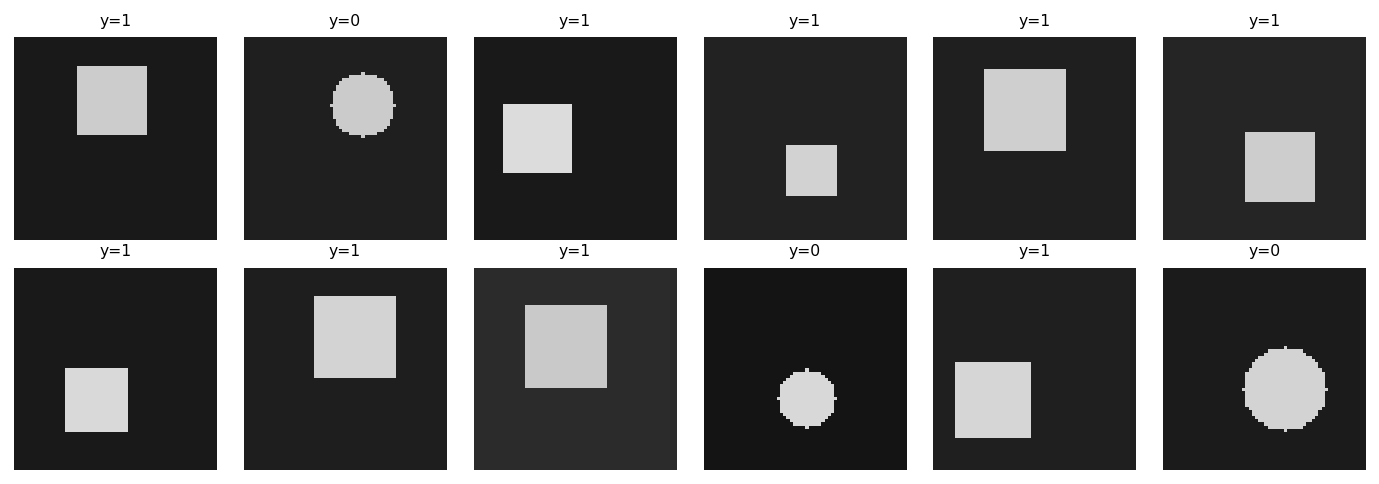

In [8]:
def draw_sample(label: int, img_size=64, bg=30, fg=210, rng=None):
    if rng is None:
        rng = np.random.RandomState(0)
    img = np.full((img_size, img_size), bg, dtype=np.uint8)

    cx = int(rng.uniform(img_size*0.3, img_size*0.7))
    cy = int(rng.uniform(img_size*0.3, img_size*0.7))
    s  = int(rng.uniform(img_size*0.12, img_size*0.22))

    if label == 0:
        yy, xx = np.ogrid[:img_size, :img_size]
        mask = (xx - cx)**2 + (yy - cy)**2 <= s*s
        img[mask] = fg
    else:
        x1, x2 = max(0, cx-s), min(img_size, cx+s)
        y1, y2 = max(0, cy-s), min(img_size, cy+s)
        img[y1:y2, x1:x2] = fg

    img3 = np.stack([img, img, img], axis=0)  # CHW
    return img3

class ShapesDS(Dataset):
    def __init__(self, n: int, p_pos: float = 0.5, label_noise: float = 0.0,
                 domain_shift: float = 0.0, seed: int = 42):
        self.n = n
        self.p_pos = p_pos
        self.label_noise = label_noise
        self.domain_shift = domain_shift
        self.rng = np.random.RandomState(seed)
        self.labels = (self.rng.rand(n) < p_pos).astype(int)

    def __len__(self): return self.n

    def __getitem__(self, idx):
        y = int(self.labels[idx])
        if self.label_noise > 0 and self.rng.rand() < self.label_noise:
            y = 1 - y

        bg = int(np.clip(30 + self.domain_shift*50 + self.rng.normal(0, 6), 0, 255))
        fg = int(np.clip(210 - self.domain_shift*40 + self.rng.normal(0, 6), 0, 255))

        x = draw_sample(y, rng=self.rng, bg=bg, fg=fg)
        x = torch.from_numpy(x).float() / 255.0
        return x, torch.tensor(y, dtype=torch.long)

def show_grid(ds: Dataset, k=12):
    imgs, titles = [], []
    for i in range(k):
        x, y = ds[i]
        imgs.append(x.permute(1,2,0).numpy())
        titles.append(f"y={int(y)}")
    cols = 6
    rows = (k + cols - 1)//cols
    plt.figure(figsize=(10, 3.5))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        ax = plt.subplot(rows, cols, i+1)
        ax.axis("off")
        ax.set_title(t, fontsize=8)
        plt.imshow(im)
    plt.tight_layout()
    plt.show()

ds_demo = ShapesDS(50, p_pos=0.5, seed=1)
show_grid(ds_demo, k=12)


## 2) Sanity checks: shape / dtype / range

Это обязательные проверки перед тем, как менять архитектуру и гиперпараметры.


In [9]:
x, y = ds_demo[0]
print("x shape:", tuple(x.shape), "dtype:", x.dtype, "min/max:", float(x.min()), float(x.max()))
print("y:", int(y), "dtype:", y.dtype)
assert x.shape == (3,64,64)
assert 0.0 <= float(x.min()) and float(x.max()) <= 1.0


x shape: (3, 64, 64) dtype: torch.float32 min/max: 0.09803921729326248 0.8313725590705872
y: 1 dtype: torch.int64


## 3) Модель: маленькая CNN (быстро и достаточно)

Дальше всё делаем на ней, чтобы эксперимент был дешёвым.


In [22]:
class SmallCNN(nn.Module):
    def __init__(self, with_dropout=False, with_bn=False):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if with_bn else nn.Identity()
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if with_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(0.4) if with_dropout else nn.Identity()
        self.fc = nn.Linear(32*16*16, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.drop(x)
        return self.fc(x)

def train_epochs(model, train_loader, dev_loader, epochs=5, lr=1e-3):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    hist = {"loss": [], "acc": []}

    for e in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            total_loss += float(loss.item()) * int(y.numel())
            total_n += int(y.numel())

        y_true, y_pred = predict_all(model, dev_loader)
        acc = accuracy_score(y_true, y_pred)
        hist["loss"].append(total_loss / max(1, total_n))
        hist["acc"].append(acc)
        print(f"epoch {e+1}: train_loss={hist['loss'][-1]:.4f} dev_acc={acc:.4f}")
    return hist

def plot_hist(hist, title=""):
    plt.figure(figsize=(9,3))
    plt.plot(hist["loss"], label="total_loss")
    plt.plot(hist["acc"], label="train_acc")
    #plt.plot(hist["dev_acc"], label="dev_acc")
    #plt.plot(hist["dev_loss"], label="dev_loss")
    plt.title(title)
    plt.legend()
    plt.show()


## 4) Overfit vs Underfit

Сначала делаем «недообучение» (мало эпох + маленький LR), потом «переобучение» (шумный dev).


epoch 1: train_loss=0.6927 dev_acc=0.6433
epoch 2: train_loss=0.6892 dev_acc=0.5900


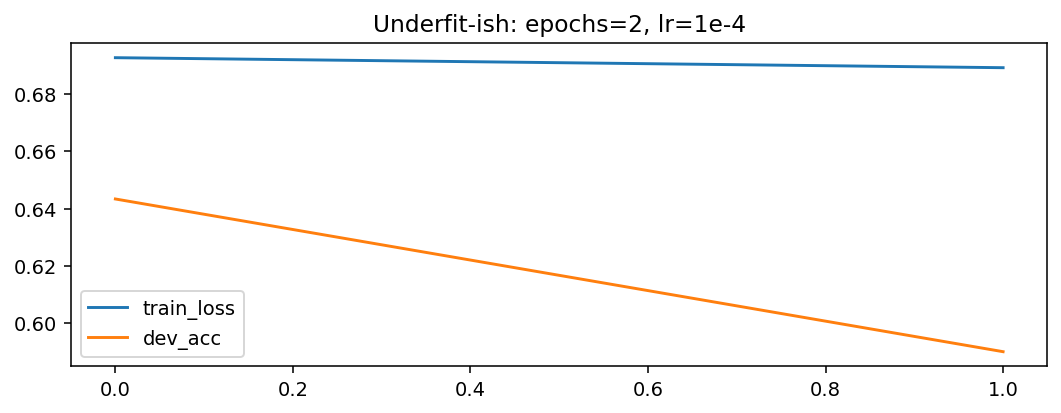

In [11]:
# Underfit-ish: few epochs + very small LR
train_ds = ShapesDS(600, p_pos=0.5, seed=10)
dev_ds   = ShapesDS(300, p_pos=0.5, seed=11)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)

hist_under = train_epochs(SmallCNN(), train_loader, dev_loader, epochs=2, lr=1e-4)
plot_hist(hist_under, "Underfit-ish: epochs=2, lr=1e-4")


epoch 1: train_loss=53.2406 dev_acc=0.5250
epoch 2: train_loss=1.9459 dev_acc=0.4750
epoch 3: train_loss=1.0939 dev_acc=0.5250
epoch 4: train_loss=0.7000 dev_acc=0.5250
epoch 5: train_loss=0.6980 dev_acc=0.4750
epoch 6: train_loss=0.6933 dev_acc=0.4750
epoch 7: train_loss=0.6933 dev_acc=0.4750
epoch 8: train_loss=0.6933 dev_acc=0.4750
epoch 9: train_loss=0.6930 dev_acc=0.4750
epoch 10: train_loss=0.6930 dev_acc=0.4750


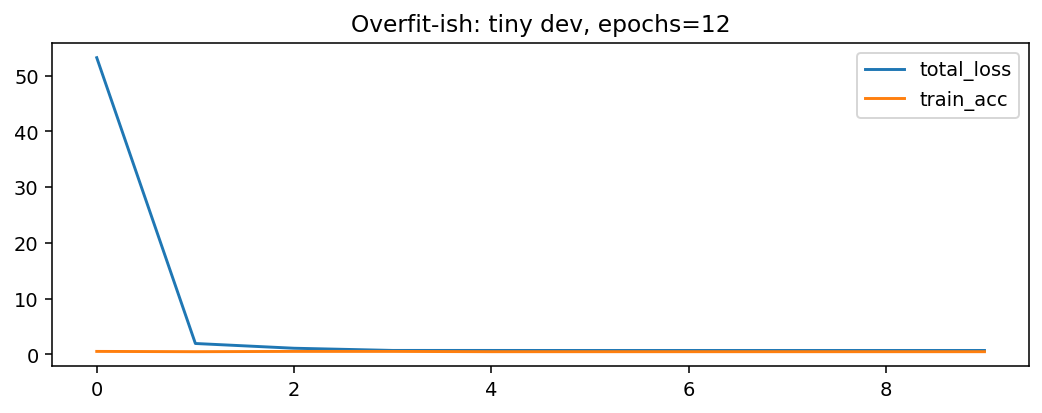

In [24]:
# Overfit-ish: tiny dev set -> noisy estimate and over-optimistic conclusions
train_ds = ShapesDS(600, p_pos=0.5, seed=20)
dev_ds   = ShapesDS(40,  p_pos=0.5, seed=21)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)

hist_over = train_epochs(SmallCNN(), train_loader, dev_loader, epochs=10, lr=1e-1)
plot_hist(hist_over, "Overfit-ish: tiny dev, epochs=12")


## 5) Learning Rate: sweep (быстро)

Обучаем по 2 эпохи и смотрим, где обучение «оживает», а где «разваливается».


In [26]:
train_ds = ShapesDS(600, p_pos=0.5, seed=30)
dev_ds   = ShapesDS(300, p_pos=0.5, seed=31)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)

lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-2, 1e-1]
results = []
for lr in lrs:
    seed_everything(42)
    model = SmallCNN()
    hist = train_epochs(model, train_loader, dev_loader, epochs=2, lr=lr)
    results.append((lr, hist["loss"][-1], hist["acc"][-1]))

print("\nLR sweep results:")
for lr, loss, acc in results:
    print(f"  lr={lr:.0e}  last_loss={loss:.4f}  last_dev_acc={acc:.4f}")


epoch 1: train_loss=0.6934 dev_acc=0.5233
epoch 2: train_loss=0.6931 dev_acc=0.5500
epoch 1: train_loss=0.6926 dev_acc=0.5633
epoch 2: train_loss=0.6914 dev_acc=0.5633
epoch 1: train_loss=0.6912 dev_acc=0.5633
epoch 2: train_loss=0.6892 dev_acc=0.5633
epoch 1: train_loss=0.6899 dev_acc=0.5633
epoch 2: train_loss=0.6813 dev_acc=0.7067
epoch 1: train_loss=0.6864 dev_acc=0.6900
epoch 2: train_loss=0.6437 dev_acc=0.8267
epoch 1: train_loss=2.4679 dev_acc=0.5633
epoch 2: train_loss=0.6925 dev_acc=0.5633
epoch 1: train_loss=40.5665 dev_acc=0.5633
epoch 2: train_loss=1.0303 dev_acc=0.5633

LR sweep results:
  lr=1e-05  last_loss=0.6931  last_dev_acc=0.5500
  lr=3e-05  last_loss=0.6914  last_dev_acc=0.5633
  lr=1e-04  last_loss=0.6892  last_dev_acc=0.5633
  lr=3e-04  last_loss=0.6813  last_dev_acc=0.7067
  lr=1e-03  last_loss=0.6437  last_dev_acc=0.8267
  lr=3e-02  last_loss=0.6925  last_dev_acc=0.5633
  lr=1e-01  last_loss=1.0303  last_dev_acc=0.5633


## 6) Дисбаланс: accuracy врёт, macro-F1 честнее

Сделаем редкий позитив: 5%.


In [27]:
train_ds = ShapesDS(1200, p_pos=0.05, seed=40)
dev_ds   = ShapesDS(600,  p_pos=0.05, seed=41)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)

model = SmallCNN()
_ = train_epochs(model, train_loader, dev_loader, epochs=5, lr=1e-3)

y_true, y_pred = predict_all(model, dev_loader)
show_report(y_true, y_pred, "Imbalance report:")
print(classification_report(y_true, y_pred, digits=3))


epoch 1: train_loss=0.2898 dev_acc=0.9500
epoch 2: train_loss=0.2151 dev_acc=0.9500
epoch 3: train_loss=0.2039 dev_acc=0.9500
epoch 4: train_loss=0.1955 dev_acc=0.9500
epoch 5: train_loss=0.1772 dev_acc=0.9500
Imbalance report:
accuracy: 0.95  macro_f1: 0.4872
confusion matrix:
 [[570   0]
 [ 30   0]]
              precision    recall  f1-score   support

           0      0.950     1.000     0.974       570
           1      0.000     0.000     0.000        30

    accuracy                          0.950       600
   macro avg      0.475     0.500     0.487       600
weighted avg      0.902     0.950     0.926       600



/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## 7) Label noise: потолок качества

Добавим 25% ошибок разметки на train и сравним с «чистой» разметкой.


epoch 1: train_loss=0.6960 dev_acc=0.5225
epoch 2: train_loss=0.6642 dev_acc=0.6875
epoch 3: train_loss=0.5954 dev_acc=0.6550
epoch 4: train_loss=0.5331 dev_acc=0.8050
epoch 5: train_loss=0.4749 dev_acc=0.8875
epoch 6: train_loss=0.3468 dev_acc=0.9500
CLEAN labels dev_acc: 0.95 macro_f1: 0.95
epoch 1: train_loss=0.6813 dev_acc=0.6825
epoch 2: train_loss=0.6099 dev_acc=0.8650
epoch 3: train_loss=0.4407 dev_acc=0.9675
epoch 4: train_loss=0.2510 dev_acc=0.9900
epoch 5: train_loss=0.0997 dev_acc=0.9950
epoch 6: train_loss=0.0429 dev_acc=0.9950
NOISY labels (25%) dev_acc: 0.995 macro_f1: 0.995


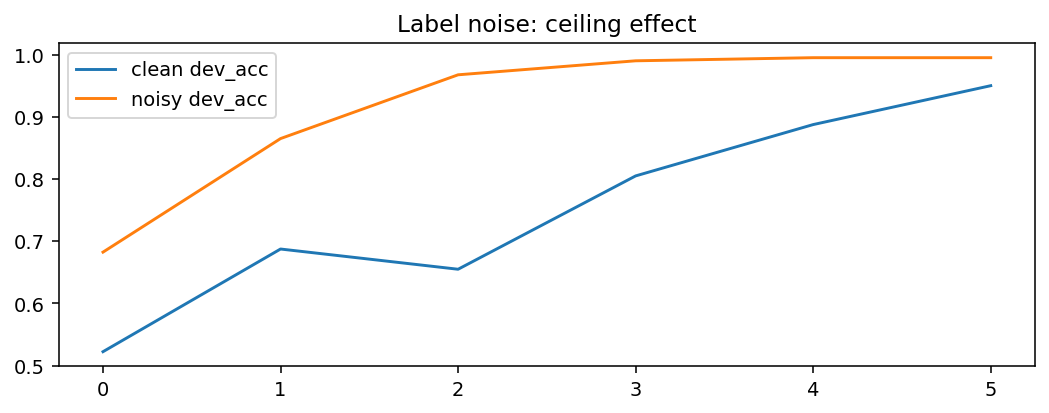

In [29]:
train_ds_clean = ShapesDS(800, p_pos=0.5, label_noise=0.0, seed=50)
train_ds_noisy = ShapesDS(800, p_pos=0.5, label_noise=0.25, seed=50)
dev_ds         = ShapesDS(400, p_pos=0.5, label_noise=0.0, seed=51)

def run_case(train_ds, name):
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
    dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)
    model = SmallCNN()
    hist = train_epochs(model, train_loader, dev_loader, epochs=6, lr=1e-3)
    y_true, y_pred = predict_all(model, dev_loader)
    print(name, "dev_acc:", round(accuracy_score(y_true, y_pred),4),
          "macro_f1:", round(f1_score(y_true, y_pred, average='macro'),4))
    return hist

hist_clean = run_case(train_ds_clean, "CLEAN labels")
hist_noisy = run_case(train_ds_noisy, "NOISY labels (25%)")

plt.figure(figsize=(9,3))
plt.plot(hist_clean["acc"], label="clean dev_acc")
plt.plot(hist_noisy["acc"], label="noisy dev_acc")
plt.title("Label noise: ceiling effect")
plt.legend()
plt.show()


## 8) Leakage: dev == train (плохая идея)

Сымитируем утечку: dev сделаем копией train и сравним с честным dev.


In [30]:
train_ds = ShapesDS(600, p_pos=0.5, seed=60)
dev_ds_honest = ShapesDS(300, p_pos=0.5, seed=61)
dev_ds_leak = train_ds  # утечка

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_h_loader = DataLoader(dev_ds_honest, batch_size=64, shuffle=False, num_workers=2)
dev_l_loader = DataLoader(dev_ds_leak, batch_size=64, shuffle=False, num_workers=2)

model = SmallCNN()
_ = train_epochs(model, train_loader, dev_h_loader, epochs=4, lr=1e-3)

y_true_h, y_pred_h = predict_all(model, dev_h_loader)
y_true_l, y_pred_l = predict_all(model, dev_l_loader)

show_report(y_true_h, y_pred_h, "Honest dev:")
show_report(y_true_l, y_pred_l, "Leaky dev (dev == train):")


epoch 1: train_loss=0.6933 dev_acc=0.5600
epoch 2: train_loss=0.6627 dev_acc=0.6333
epoch 3: train_loss=0.6110 dev_acc=0.7233
epoch 4: train_loss=0.5319 dev_acc=0.7700
Honest dev:
accuracy: 0.77  macro_f1: 0.7686
confusion matrix:
 [[104  33]
 [ 36 127]]
Leaky dev (dev == train):
accuracy: 0.8533  macro_f1: 0.8533
confusion matrix:
 [[257  25]
 [ 63 255]]


## 9) Ошибка `model.eval()` (Dropout / BatchNorm)

Если оценивать в train-режиме, метрика «плавает». Покажем это.


In [31]:
train_ds = ShapesDS(800, p_pos=0.5, seed=70)
dev_ds   = ShapesDS(400, p_pos=0.5, seed=71)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader   = DataLoader(dev_ds, batch_size=64, shuffle=False, num_workers=2)

model = SmallCNN(with_dropout=True, with_bn=True)
_ = train_epochs(model, train_loader, dev_loader, epochs=4, lr=1e-3)

# correct eval
y_true, y_pred = predict_all(model, dev_loader)
acc_ok = accuracy_score(y_true, y_pred)

# WRONG: evaluate in train mode
@torch.no_grad()
def eval_in_train_mode(model, loader):
    model.train()  # wrong on purpose
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        pred = model(x).argmax(1).cpu().numpy()
        ys.append(y.numpy()); ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

acc_wrong = []
for _ in range(5):
    yt, yp = eval_in_train_mode(model, dev_loader)
    acc_wrong.append(accuracy_score(yt, yp))

print("Correct eval acc:", round(acc_ok,4))
print("WRONG (train-mode) eval acc samples:", [round(x,4) for x in acc_wrong])
print("Spread:", round(max(acc_wrong)-min(acc_wrong),4))


epoch 1: train_loss=0.8647 dev_acc=0.4875
epoch 2: train_loss=0.3467 dev_acc=0.4675
epoch 3: train_loss=0.0758 dev_acc=0.4675
epoch 4: train_loss=0.0156 dev_acc=0.4675
Correct eval acc: 0.4675
WRONG (train-mode) eval acc samples: [1.0, 1.0, 1.0, 0.9975, 1.0]
Spread: 0.0025


## 10) BatchNorm и маленький batch

Сравним batch=8 и batch=64 для модели с BatchNorm.


In [33]:
train_ds = ShapesDS(1200, p_pos=0.5, seed=80)
dev_ds   = ShapesDS(600,  p_pos=0.5, seed=81)

def run_bn(batch):
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True, num_workers=2)
    dev_loader   = DataLoader(dev_ds, batch_size=batch, shuffle=False, num_workers=2)
    model = SmallCNN(with_bn=True)
    hist = train_epochs(model, train_loader, dev_loader, epochs=4, lr=1e-3)
    return hist["acc"][-1]

acc_b8  = run_bn(8)
acc_b64 = run_bn(64)
print("Final acc batch=8 :", round(acc_b8,4))
print("Final acc batch=64:", round(acc_b64,4))


epoch 1: train_loss=0.1724 dev_acc=1.0000
epoch 2: train_loss=0.0012 dev_acc=1.0000
epoch 3: train_loss=0.0005 dev_acc=1.0000
epoch 4: train_loss=0.0004 dev_acc=1.0000
epoch 1: train_loss=0.6912 dev_acc=0.5050
epoch 2: train_loss=0.0909 dev_acc=0.5050
epoch 3: train_loss=0.0054 dev_acc=0.5050
epoch 4: train_loss=0.0018 dev_acc=1.0000
Final acc batch=8 : 1.0
Final acc batch=64: 1.0


## 11) Ablation: domain shift

Dev “портим” domain shift, тренируемся на чистом train и смотрим результат.


In [34]:
train_ds = ShapesDS(1000, p_pos=0.5, domain_shift=0.0, seed=90)
dev_ds_shift = ShapesDS(500, p_pos=0.5, domain_shift=1.0, seed=91)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
dev_loader_shift = DataLoader(dev_ds_shift, batch_size=64, shuffle=False, num_workers=2)

model = SmallCNN()
_ = train_epochs(model, train_loader, dev_loader_shift, epochs=5, lr=1e-3)
y_true, y_pred = predict_all(model, dev_loader_shift)
show_report(y_true, y_pred, "Baseline under domain shift:")


epoch 1: train_loss=0.6838 dev_acc=0.4940
epoch 2: train_loss=0.6271 dev_acc=0.4940
epoch 3: train_loss=0.5374 dev_acc=0.4940
epoch 4: train_loss=0.4599 dev_acc=0.4940
epoch 5: train_loss=0.3131 dev_acc=0.4940
Baseline under domain shift:
accuracy: 0.494  macro_f1: 0.3307
confusion matrix:
 [[  0 253]
 [  0 247]]


## 12) Итог: мини-чек-лист

- данные визуально ок?  
- разметка ок? (FP/FN глазами)  
- утечки исключены?  
- baseline обгоняем?  
- LR/режимы train/eval корректны?  
- ablation по одной правке  
